<h1>Prompt Image Matching Process</h1>

In [1]:
import pandas as pd

tagged_sample_df = pd.read_csv('datasets/gpt2_florence_sample_dataset_tagged_2025_02_19_18_32_58.csv')
tagged_sample_df.head()

,file_name,tagging_vitgpt2,florence_short,florence_long
0,5dec6d6e40bd4d6bb3016f05bef8c3ae.jpg,a baby sitting on a table with a toy,A baby sitting on the floor playing with color...,The image shows a baby sitting on the floor wi...
1,5104d2b1073347a7acf5a7cc0d5e1d19.jpg,a woman holding a red and white teddy bear,A woman in a red scarf and mittens blowing snow.,The image shows a young woman with long brown ...
2,f73e688021f04f128db6f1f399244d9b.jpg,a pink rose in a white vase with flowers,A circle of pink roses with green leaves and r...,The image is a flat lay of a wreath made of pi...
3,20c657d94d5b4993a2e04879c8bdcf0d.jpg,a young woman standing next to a young girl,A woman in a red dress holding hands with a ma...,The image shows a young woman and a young man ...
4,7defda9553cd45c0aecad952d6eb8fa0.jpg,a table with a bunch of different colored flow...,A bunch of yellow and red tulips next to an ea...,The image is a flat lay of colorful Easter egg...


<h2>Labelled Images</h2>

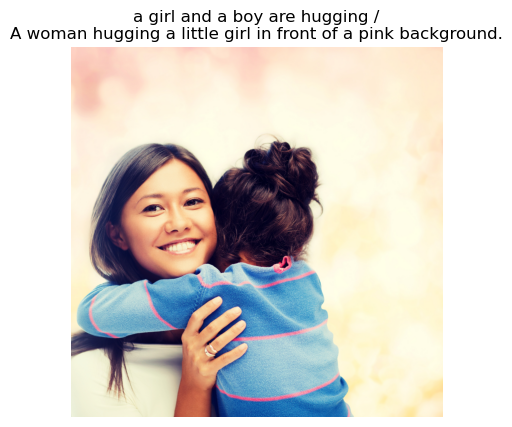

In [2]:
id = 169
image_name = tagged_sample_df.iloc[id].file_name
image_tag = tagged_sample_df.iloc[id].tagging_vitgpt2 + "/\n"+ tagged_sample_df.iloc[id].florence_short
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_filename = '../sample_imagesv2/'+image_name
#image_filename = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg' 
img = mpimg.imread(image_filename)
plt.figure()
plt.imshow(img)
plt.axis("off")
plt.title(image_tag)
plt.show()

<h2>Text Preprocessing </h2>

In [3]:
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk import SnowballStemmer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#print(lemmatizer.lemmatize("cats"))


def text_preprocess(text_in):
    stopwords_ = stopwords.words('english')
    stopwords_.append('image')

    pattern = r'[^a-zA-Z.,?\s]' #find unwanted characters (non-alphanumeric and non-whitespace)
    clean_text = re.sub(pattern, ' ', text_in.lower())#replace them with an empty string
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()
    word_list = word_tokenize(clean_text)
    word_list = [word for word in word_list if word not in stopwords_]
    
    Nw = len(word_list)#number of words
    
    lemmatizer = WordNetLemmatizer()
    #stemmer = SnowballStemmer('english') #english stemmer
    for i in range(Nw):
        word = word_list[i]
        #word = stemmer.stem(word)
        word = lemmatizer.lemmatize(word)
        word_list[i] = word
    
    clean_text = ' '.join(word_list)
    return clean_text
    

In [4]:
id = 10
text_in = tagged_sample_df.iloc[id].florence_long
print(text_in,'\n\n',text_preprocess(text_in))

In this image, we can see a young man working on a wall. He is wearing
a green t-shirt and white gloves and is holding a trowel in his right
hand. He appears to be in the process of applying plaster to the wall.
The wall is made of concrete and there is a window on the left side of
the image. The man is standing on a ladder and is focused on his work.
The image is taken from a low angle, looking up at the wall and the
man. 

 , see young man working wall . wearing green shirt white glove holding trowel right hand . appears process applying plaster wall . wall made concrete window left side . man standing ladder focused work . taken low angle , looking wall man .


In [5]:
tagged_sample_df['features'] = tagged_sample_df['florence_long'].apply(text_preprocess)

tagged_sample_df[['features']].head()

,features
0,show baby sitting floor big smile face . baby ...
1,"show young woman long brown hair , wearing red..."
2,flat lay wreath made pink rose . rose arranged...
3,show young woman young man walking hand hand p...
4,flat lay colorful easter egg tulip white backg...


<h2>Text Matching Algorithm - TFIDF</h2>

In [6]:
from sklearn.feature_extraction.text import CountVectorizer ,TfidfVectorizer

n_feats = 200
tfidf = TfidfVectorizer(stop_words='english') #Term Frequency Matrix  max_features=n_feats
X = tfidf.fit_transform(tagged_sample_df['features']).toarray()
X.shape #get feature matrix size

(500, 1757)

In [7]:
from sklearn.metrics.pairwise import cosine_similarity 
import numpy as np
#image_recommender
def image_recommender(tagged_sample_df_,tagger,tf_idf,X_matrix,text,thr_=0.35,top_n=10):
    X_text = tf_idf.transform([text])
    cosine_sim_matrix = cosine_similarity(X_text,X_matrix)
    cosine_sim_matrix = cosine_sim_matrix[0]
    sort_ids = np.argsort(cosine_sim_matrix)#sort 
    sort_ids = sort_ids[::-1]#descendingly
    features_df_rec = tagged_sample_df_.loc[sort_ids,['file_name',tagger]]
    features_df_rec['sim'] = cosine_sim_matrix[sort_ids]
    output_df_ = features_df_rec[features_df_rec['sim'] > thr_]
    output_df = output_df_.iloc[0:top_n,:]
    return output_df 

In [8]:
text = 'a group of musicians singing'
tagger = 'florence_long'
top_k = 10

import time

tic = time.time()
text_in = text_preprocess(text)
output_df = image_recommender(tagged_sample_df,tagger,tfidf,
                               X,text_in,thr_=0.25,top_n=top_k)
toc = time.time()
# Print elapsed time
print(f"Execution Time: {toc - tic:.4f} seconds")

Execution Time: 0.0063 seconds


In [9]:
output_df

,file_name,florence_long,sim
351,714da92a2613431c8b87afaa064dc6d9.jpg,The image shows a group of nine business peopl...,0.296818


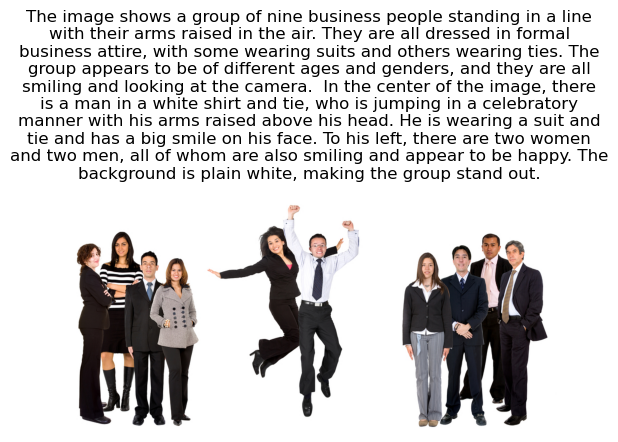

In [10]:
for i in range(len(output_df)):
    image_name = output_df.iloc[i].file_name
    image_tag =  output_df.iloc[i].florence_long
    image_filename = '../sample_imagesv2/'+image_name
    #image_filename = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg' 
    img = mpimg.imread(image_filename)
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_tag)
    plt.show()

In [11]:
#pip install dill


<h2>Text Matching Algorithm - SBERT</h2>

In [12]:
#pip install sentence_transformers 

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Load a pre-trained SBERT model
model = SentenceTransformer("all-MiniLM-L6-v2")  # Optimized for sentence similarity

# Example paragraphs
#paragraph1 = "Artificial Intelligence is transforming the world by automating tasks and making predictions."
#paragraph2 = "Machine learning is revolutionizing industries by enabling automation and predictive analytics."

paragraph1 = "a man and a woman"
paragraph2 = "a male and a female"
# Generate embeddings
embedding1 = model.encode(paragraph1, convert_to_tensor=True)
embedding2 = model.encode(paragraph2, convert_to_tensor=True)

# Compute Cosine Similarity
similarity_score = util.pytorch_cos_sim(embedding1, embedding2).item()

print(f"Similarity Score: {similarity_score:.4f}")  # Output: 0.85 (Higher means more similar)

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")  # Optimized for sentence similarity
sbert_corpus_embeddings = []
ns = len(tagged_sample_df)
for i in range(ns):
    paragraph2 = tagged_sample_df.at[i,'features']
    embedding2 = model.encode(paragraph2, convert_to_tensor=True)
    sbert_corpus_embeddings.append(embedding2)

In [ ]:
def sbert_image_recommender(tagged_sample_df_,tagger,text,thr_=0.35,top_n=10):
    embedding1 = model.encode(text, convert_to_tensor=True)
    ns = len(tagged_sample_df_)
    bert_score_list = []
    for i in range(ns):
        embedding2 = sbert_corpus_embeddings[i]
        similarity_score = util.pytorch_cos_sim(embedding1, embedding2).item()
        bert_score_list.append(similarity_score)    
    output_df_ = tagged_sample_df_.copy()
    output_df_['sbert_sim'] = bert_score_list
    output_df_ = output_df_.sort_values(by='sbert_sim', ascending=False)
    c_output_df = output_df_.iloc[0:top_n,:]
    return c_output_df

In [ ]:
import time

text = 'people drinking wine'
text_in = text_preprocess(text)


tic = time.time()
sbert_output_df = sbert_image_recommender(tagged_sample_df,tagger,text_in,thr_=0.00,top_n=10)
toc = time.time()
# Print elapsed time
print(f"Execution Time: {toc - tic:.4f} seconds")

In [ ]:
sbert_output_df.head()

In [ ]:
print('Number of records:',len(sbert_output_df))

In [ ]:
for i in range(len(sbert_output_df)):
    image_name = sbert_output_df.iloc[i].file_name
    image_tag =  sbert_output_df.iloc[i].florence_long
    image_filename = '../sample_imagesv2/'+image_name
    #image_filename = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg' 
    img = mpimg.imread(image_filename)
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_tag)
    plt.show()

<h2>Text Matching Algorithm - Word2Vec</h2>

In [ ]:
#https://tedboy.github.io/nlps/generated/generated/gensim.models.Word2Vec.html
import gensim.downloader
# Show all available models in gensim-data
gensim_pretrains = list(gensim.downloader.info()['models'].keys())

N = len(gensim_pretrains)
for i in range(N):
    pretrain_model_name = gensim_pretrains[i]
    print("[",i+1,"] ", pretrain_model_name)

In [ ]:
model_i = 4 #ruscorpora(deja), glove-twitter-25 (deja), word2vec-google-news-300 (deja)
pretrain_model_name = gensim_pretrains[model_i-1]
word2vec_model = gensim.downloader.load(pretrain_model_name)


In [ ]:
text_in = 'technology'
print(f'Pretrain model: {pretrain_model_name} -> Word: {text_in}')
list_sim = word2vec_model.most_similar(text_in)

for sim in list_sim:
    print(sim)

In [ ]:

text_vec = word2vec_model[text_in]
print('Vector representation of %s :(%d x 1)'%(text_in,text_vec.shape[0]))
print(text_vec)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity 

word1 = 'car'
word2 = 'truck'

word2vec_1 = word2vec_model[word1].reshape(1,-1)
word2vec_2 = word2vec_model[word2].reshape(1,-1)

w2v_cosine_similarity = cosine_similarity(word2vec_1,word2vec_2)
print(f'{word1} vs {word2} = {w2v_cosine_similarity[0][0]}')

In [ ]:
#Save results
from datetime import datetime
# Get the current date and time
now = datetime.now()
timestamp_str = now.strftime('%Y_%m_%d_%H_%M_%S')
print(timestamp_str)

In [ ]:
features = tfidf.get_feature_names_out().tolist()
features[0]

In [ ]:
import numpy as np
#X
features = tfidf.get_feature_names_out().tolist()
Nf = len(features)
word_embeddings = {}
ei = 0
for i in range(Nf):
    feature = features[i]  
    if feature in word2vec_model:
        word_embeddings[feature] = word2vec_model[feature].reshape(1,-1)
    else:
        word_embeddings[feature] = np.zeros(word2vec_model.vector_size).reshape(1,-1)
        ei+=1
        print(ei, "missing-->",feature)
    #print(i)
word_embeddings

In [ ]:
X_emb = np.zeros((X.shape[0],word2vec_model.vector_size))

for i in range(X_emb.shape[0]):
    for j in range(Nf):
        vec = word_embeddings[features[j]]*X[i][j]   
        X_emb[i] +=  vec.reshape(-1,)
    X_emb[i] /= np.sum(X[i])

X_emb

In [ ]:
X_text = tfidf.transform([text])
X_text.shape

In [ ]:
def text2emb(text_in):
    text_out = text_preprocess(text_in)
    pattern = r'[^a-zA-Z\s]' #find unwanted characters (non-alphanumeric and non-whitespace)
    clean_text = re.sub(pattern, ' ', text_out.lower())#replace them with an empty string
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()
    word_list = word_tokenize(clean_text)
    N_w = len(word_list)
    
    text_emb = np.zeros((1,word2vec_model.vector_size))
    
    for i in range(N_w):
        feature = word_list[i]
        if feature in word2vec_model:
            vec = word2vec_model[feature].reshape(1,-1)
        else:
            vec = np.zeros(word2vec_model.vector_size).reshape(1,-1)
            
        text_emb += vec
        
    if N_w == 0:
        N_w = 1
    text_emb /= N_w
    
    return text_emb
    

In [ ]:
#text2emb('test').shape

In [ ]:
def wordemb_image_recommender(tagged_sample_df_,tagger,tf_idf,X_emb_matrix,text,thr_=0.35,top_n=10):
    """
    X_text = tf_idf.transform([text])
    X_emb_text = np.zeros((1,word2vec_model.vector_size))#make dynamic
    for j in range(Nf):
        vec = word_embeddings[features[j]]*X_text[0][j]   
        X_emb_text[0] +=  vec.reshape(-1,)
    X_emb_text[i] /= np.sum(X[i])
    """
    X_emb_text = text2emb(text)
    
    cosine_sim_matrix = cosine_similarity(X_emb_text,X_emb_matrix)
    cosine_sim_matrix = cosine_sim_matrix[0]
    sort_ids = np.argsort(cosine_sim_matrix)#sort 
    sort_ids = sort_ids[::-1]#descendingly
    features_df_rec = tagged_sample_df_.loc[sort_ids,['file_name',tagger]]
    features_df_rec['sim'] = cosine_sim_matrix[sort_ids]
    output_df_ = features_df_rec[features_df_rec['sim'] > thr_]
    output_df = output_df_.iloc[0:top_n,:]
    return output_df 

In [ ]:
import time

text = 'careers in engineering'
text_in = text_preprocess(text)


tic = time.time()
word_emb_output_df = wordemb_image_recommender(tagged_sample_df,tagger,[],X_emb,text_in,thr_=0.00,top_n=10)
toc = time.time()
# Print elapsed time
print(f"Execution Time: {toc - tic:.4f} seconds")

In [ ]:
word_emb_output_df

In [ ]:
for i in range(len(word_emb_output_df)):
    image_name = word_emb_output_df.iloc[i].file_name
    image_tag =  word_emb_output_df.iloc[i].florence_long
    image_filename = '../sample_imagesv2/'+image_name
    #image_filename = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg' 
    img = mpimg.imread(image_filename)
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_tag)
    plt.show()

<h2>Storing the solution</h2>

In [ ]:
import dill as pickle

with open('models/image_recommender_model_florence_long_tfidf_files_%s.pkl'%timestamp_str, 'wb') as f:
    pickle.dump(image_recommender, f)
    pickle.dump(tagged_sample_df, f)
    pickle.dump(tfidf, f)
    pickle.dump(X, f)

In [ ]:
with open('models/image_recommender_model_florence_long_tfidf_files_%s.pkl'%timestamp_str, 'rb') as f:
    system_image_recommender = pickle.load(f)
    tagged_sample_df = pickle.load(f)
    tfidf = pickle.load(f)
    X_matrix = pickle.load(f)
    

tagger = 'florence_long'
output_df = system_image_recommender(tagged_sample_df,tagger,tfidf,
                              X_matrix,text,thr_=0.0,top_n=10)
output_df